Data Loading: The IMDb movie review dataset is loaded using Pandas. The head() function displays the first five records, shape shows the dataset dimensions, and info() provides information about columns, data types, and missing values.

In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/IMDB Dataset.csv",
    encoding="utf-8",
    engine="python"
)

print(df.head())
print(df.shape)
print(df.info())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
(50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


Class Distribution: The column names are displayed, and value_counts() is used to check the number of positive and negative movie reviews in the dataset.

In [ ]:
print(df.columns)
print(df["sentiment"].value_counts())

Index(['review', 'sentiment'], dtype='object')
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


Data Inspection & EDA

Check missing values and duplicates:

In [ ]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

review       0
sentiment    0
dtype: int64
Duplicates: 418


Sentiment Distribution: A count plot is used to visualize the number of positive and negative reviews in the IMDb dataset. This helps check whether the sentiment classes are balanced.

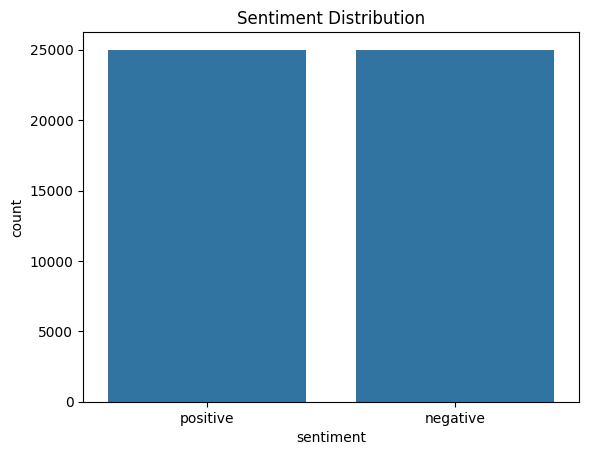

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Distribution")
plt.show()

Review Length Analysis: The length of each review is calculated and stored in a new column. A histogram is then used to visualize the distribution of review lengths and understand how long the reviews are.

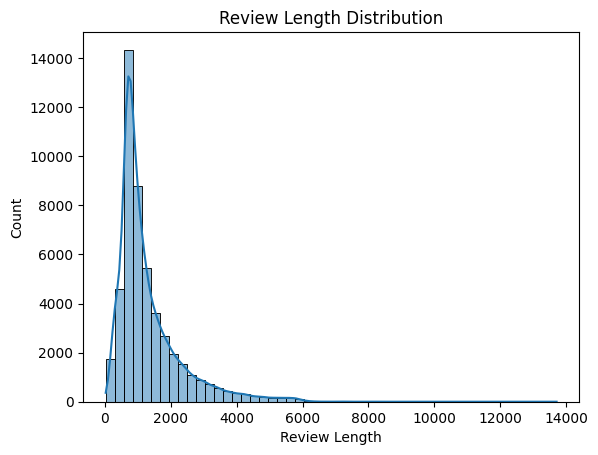

In [ ]:
df["review_length"] = df["review"].str.len()

sns.histplot(data=df, x="review_length", bins=50, kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.show()

Review Length by Sentiment: A box plot is used to compare the distribution of review lengths between positive and negative reviews. It also helps identify the median, spread, and possible outliers.

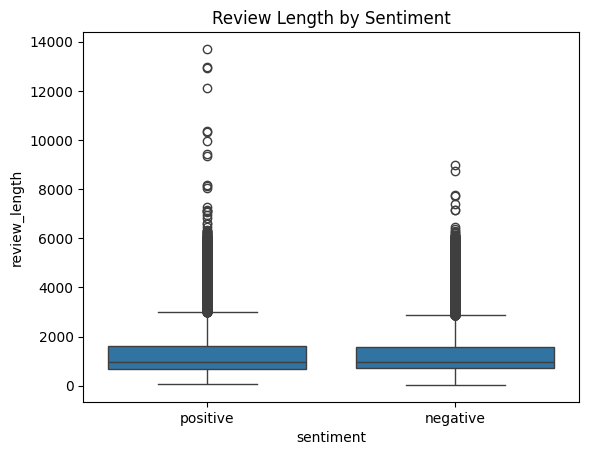

In [ ]:
sns.boxplot(data=df, x="sentiment", y="review_length")
plt.title("Review Length by Sentiment")
plt.show()

Sentiment Percentage: A pie chart is used to show the percentage distribution of positive and negative reviews. It provides a clear visual representation of the proportion of each sentiment class.

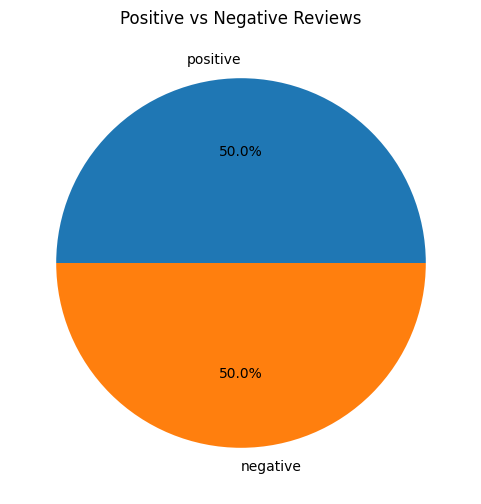

In [ ]:
df["sentiment"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Positive vs Negative Reviews")
plt.ylabel("")
plt.show()

. Data Cleaning

Remove missing reviews and duplicates:

In [ ]:
df = df.dropna()
df = df.drop_duplicates()

print(df.shape)

(49582, 3)


Text Cleaning: The reviews are converted to lowercase, HTML tags and special characters are removed, extra spaces are cleaned, and the processed text is stored in a new clean_review column.

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_review"] = df["review"].apply(clean_text)

Feature Engineering

Create useful text-based features:
These can help understand the relationship between review length and sentiment.

For the main NLP model, the actual review text will be transformed into numerical features using TF-IDF.

In [ ]:
df["word_count"] = df["clean_review"].str.split().str.len()
df["char_count"] = df["clean_review"].str.len()

TF-IDF Feature Extraction: TF-IDF is used to convert cleaned text into numerical features. A maximum of 5,000 features is selected, while common English stop words are removed.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

Convert reviews into numerical vectors:
TF-IDF converts text into numerical values based on how important each word is in the reviews.Feature and Target Creation: The cleaned reviews are converted into numerical TF-IDF features and stored in X, while the sentiment column is assigned as the target variable y.

In [ ]:
X = vectorizer.fit_transform(df["clean_review"])

y = df["sentiment"]

Scaling

For TF-IDF, additional StandardScaler is generally not necessary because TF-IDF already produces normalized/sparse numerical features.
Additional scaling was not applied because TF-IDF already produces appropriately weighted and normalized sparse text features.

Model Training
Train-Test Split: The TF-IDF features and sentiment labels are divided into 80% training and 20% testing data. Stratification is used to maintain the same sentiment distribution in both sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Model Selection: Three classification models—Logistic Regression, Naive Bayes, and Linear SVM—are defined in a dictionary for training and performance comparison.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

Model Training and Evaluation: Each classification model is trained on the training data and tested on unseen data. Accuracy, precision, recall, and F1 score are calculated to evaluate and compare model performance.

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results[name] = [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted")
    ]

    print("\n", name)
    print("Accuracy:", results[name][0])
    print("Precision:", results[name][1])
    print("Recall:", results[name][2])
    print("F1 Score:", results[name][3])


 Logistic Regression
Accuracy: 0.8854492285973581
Precision: 0.8857802371844788
Recall: 0.8854492285973581
F1 Score: 0.8854173262971518

 Naive Bayes
Accuracy: 0.8540889381869518
Precision: 0.8541537629083493
Recall: 0.8540889381869518
F1 Score: 0.8540775603106924

 Linear SVM
Accuracy: 0.8820207724110114
Precision: 0.8820581777249883
Recall: 0.8820207724110114
F1 Score: 0.8820152201068089


Experimentation & Comparison
Model Comparison: The evaluation results are converted into a DataFrame to provide a clear comparison of Accuracy, Precision, Recall, and F1 Score for all classification models.

In [22]:
results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1 Score"]
).T

print(results_df)

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.885449   0.885780  0.885449  0.885417
Naive Bayes          0.854089   0.854154  0.854089  0.854078
Linear SVM           0.882021   0.882058  0.882021  0.882015


Model Accuracy Comparison: A bar chart is used to visually compare the accuracy scores of the three classification models. This makes it easy to see the accuracy achieved by each model.

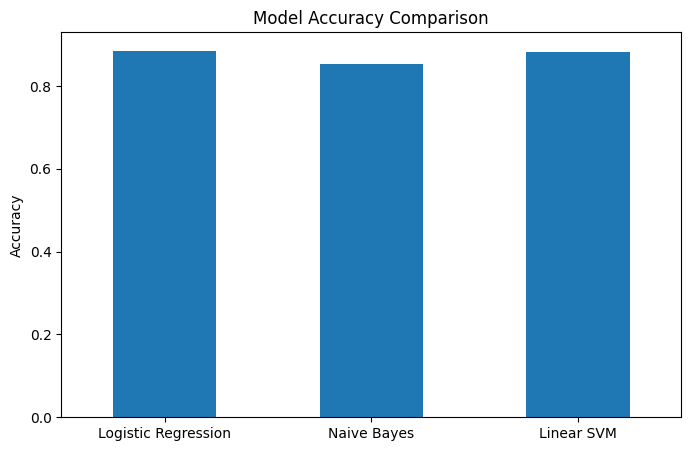

In [23]:
results_df["Accuracy"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

Model Saving

Save both the model and TF-IDF vectorizer.

For example, if Linear SVM is your selected model:
Model Saving: The final Linear SVM model is trained using the training data and saved with Joblib. The TF-IDF vectorizer is also saved so that the same text-processing method can be used for future predictions. This allows the trained sentiment-analysis model to be reused without retraining.

In [24]:
import joblib

final_model = LinearSVC()

final_model.fit(X_train, y_train)

joblib.dump(final_model, "imdb_sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


Streamlit Prototype: A Streamlit web application is created for IMDb sentiment prediction. The trained model and TF-IDF vectorizer are loaded from saved files. Users can enter a movie review, which is converted into TF-IDF features and passed to the trained Linear SVM model. The application then displays the predicted sentiment as positive or negative.

The IMDB Dataset of 50K Movie Reviews is an NLP dataset containing movie reviews labeled as positive or negative. The objective of this project is to automatically classify the sentiment of a movie review using machine learning techniques.

The dataset was loaded using Pandas and inspected through its structure, class distribution, missing values, duplicate records, and review lengths. Exploratory Data Analysis was performed using count plots, pie charts, histograms, and box plots to understand the distribution of sentiments and review lengths.

During data cleaning, missing values and duplicate reviews were removed. The review text was converted to lowercase, HTML tags and unnecessary characters were removed, and extra spaces were cleaned. Additional features such as word count and character count were created to analyze review characteristics.

Since the dataset contains text data, TF-IDF Vectorization was used to convert movie reviews into numerical feature vectors. Additional scaling was not required because TF-IDF produces normalized sparse numerical features. The data was divided into training and testing sets using a stratified 80/20 split.

Multiple classification models, including Logistic Regression, Multinomial Naive Bayes, and Linear SVM, were trained and compared. Accuracy, Precision, Recall, and F1-score were used to evaluate the models. A model comparison chart was also created to visualize their performance.
The selected model and TF-IDF vectorizer were saved using Joblib. A Streamlit-based prototype was designed where users can enter a movie review and receive a predicted positive or negative sentiment. The project demonstrates how NLP and machine learning can be used to automatically analyze opinions expressed in movie reviews.